In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [9]:
# Create a simple dataset
# X: feature (e.g., house size in sq ft)
# y: target (e.g., house price in $1000s)

X = np.array([[1000], [1500], [2000], [2500], [3000], [1200], [2800]])
y = np.array([150, 200, 250, 300, 350, 180, 320])  

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training data:")
print("X_train:", X_train.flatten())
print("y_train:", y_train)
print("Testing data:")
print("X_test:", X_test.flatten())
print("y_test:", y_test)

Training data:
X_train: [2000 3000 2500 2800]
y_train: [250 350 300 320]
Testing data:
X_test: [1000 1500 1200]
y_test: [150 200 180]


In [10]:
# Create and train the linear regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Get the coefficients
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions:")
for i in range(len(X_test)):
    print(f"Size: {X_test[i][0]} sq ft -> Predicted Price: ${y_pred[i]*1000:.0f}, Actual Price: ${y_test[i]*1000:.0f}")

Intercept: 57.70925110132157
Coefficient: 0.0960352422907489
Predictions:
Size: 1000 sq ft -> Predicted Price: $153744, Actual Price: $150000
Size: 1500 sq ft -> Predicted Price: $201762, Actual Price: $200000
Size: 1200 sq ft -> Predicted Price: $172952, Actual Price: $180000


Mean Squared Error: 22.27


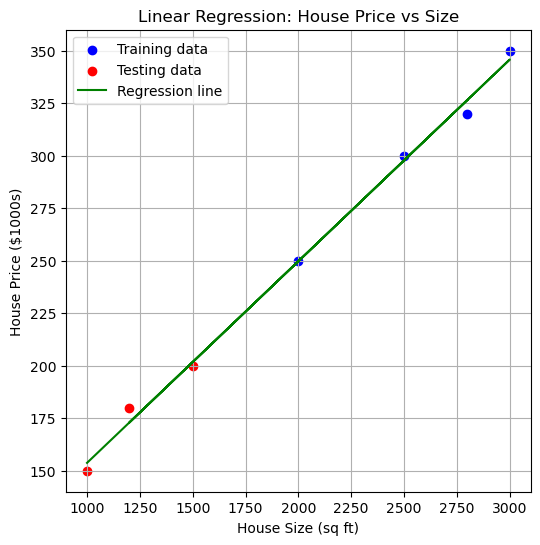

Predicted price for a 1800 sq ft house: $230573


In [11]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Visualize the results
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Testing data')
plt.plot(X, model.predict(X), color='green', label='Regression line')
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price ($1000s)')
plt.title('Linear Regression: House Price vs Size')
plt.legend()
plt.grid(True)
plt.show()

# Predict a new value
new_size = np.array([[1800]])
predicted_price = model.predict(new_size)
print(f"Predicted price for a 1800 sq ft house: ${predicted_price[0]*1000:.0f}")

In [12]:
# Input test data from user
print("Enter house sizes (in sq ft) separated by commas to predict prices:")
user_input = input("Sizes: ")
sizes = [int(x.strip()) for x in user_input.split(',') if x.strip()]
if sizes:
    test_X = np.array(sizes).reshape(-1, 1)
    predictions = model.predict(test_X)
    print("Predictions:")
    for size, price in zip(sizes, predictions):
        print(f"Size: {size} sq ft -> Predicted Price: ${price*1000:.0f}")
else:
    print("No valid sizes entered.")

Enter house sizes (in sq ft) separated by commas to predict prices:
Predictions:
Size: 1522 sq ft -> Predicted Price: $203875


In [13]:
# Check if the linear model is the best fit
from sklearn.metrics import r2_score

# Calculate R-squared for the test set
r2 = r2_score(y_test, y_pred)
print(f"R-squared (coefficient of determination): {r2:.4f}")

if r2 > 0.8:
    print("The linear model is a good fit (R-squared > 0.8).")
elif r2 > 0.6:
    print("The linear model is a moderate fit (0.6 < R-squared <= 0.8).")
else:
    print("The linear model is a poor fit (R-squared <= 0.6). Consider using a different model or preprocessing the data.")

# Since there are outliers in the data, linear regression might not be the best choice.
# You could try robust regression methods like RANSAC or Huber regression for datasets with outliers.

R-squared (coefficient of determination): 0.9473
The linear model is a good fit (R-squared > 0.8).
